# Does Arbitrage Exist Between Polymarket and Kalshi? If So, Can You Exploit It?

If both platforms list the same game,\
do their books differ enough to profit after fees?

In [1]:
%matplotlib inline
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
from IPython.display import Markdown, display

In [2]:
GREEN = "#3d7356"
CLAY = "#c2703d"
INK = "#1c1c1a"
MUTED = "#6e6e6c"
GRID = "#ededeb"
BASELINE = "#d9d9d7"
SURFACE = "#fafaf8"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "figure.dpi": 110,
})

pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(60)


def fmt_count(col):
    return pl.col(col).map_elements(lambda n: f"{n:,}", return_dtype=pl.String)


def fmt_cents(col):
    return pl.format("{}¢", (pl.col(col) * 100).round(2))


def fmt_secs(col):
    return pl.format("{}s", pl.col(col).round(1))


def fmt_pct(col):
    return pl.format("{}%", (pl.col(col) * 100).round(1))

## What is arbitrage
If you can buy apples on one side of Bleeker street for 7 then cross the street and sell the apples for 10, that is arbitrage. You just made a profit of 3. Arbitrage is the name of this phenomenon where the same item has different prices in different markets. Profiting off of an arbitrage opportunity is called exploiting it.

## What is a bid ask spread
On a prediction market, buyers post "bids" which are the prices they're willing to pay and sellers post "asks" which are the prices they're willing to accept. The "best bid" is the highest bid and the "best ask" is the lowest ask. The gap between them is the bid-ask spread.

The price is considered to be somewhere in the bid ask spread interval.

A contract with a best bid of 47¢ and a best ask of 49¢ has a 2¢ spread.\
(The price may be listed at 48¢ at this time)\
If you want to buy instantly you pay the ask (49¢).
If you want to sell instantly you get the bid (47¢). 

Both Kalshi and Polymarket are order book exchanges which list bids and asks\
as well as the amount of each of these (i.e. do you want to sell 1 contract or 100 at that ask?)

## Method
We compare the best bid and best ask on each platform at every order book state change.\
Arbitrage exists when one platform's best bid exceeds the other's best ask by more than the combined fees.

### Episodes
Consecutive book states where the deviation stays open are grouped into one **episode**.\
An episode starts at the state where the books first cross and ends at the first state where they uncross.

So one episode is one arbitrage opportunity.\
Each carries a
- duration
- peak deviation
- bottleneck volume

### Bottleneck Volume
Exploiting an arbitrage opportunity has two legs: a buy on one platform and a sell on the other. The bottleneck volume is the minimum number of contracts available at the best price across those two sides at any point during the episode.

Whichever side is thinner limits how many contracts you can actually trade. Anything beyond that means walking the book to worse prices.

### Taker vs Maker
Exchanges want to have liquidity which means there is an active pool of buyers and sellers willing to trade with each other. If they don't have liquidity this is like a restaurant owner with an empty restaurant so it's easy to see why they want liquidity.

A taker takes liquidity from the market. They come in and buy or sell immediately based on the best bid or best ask already on the books.

A maker creates liquidity. They put bids and asks on the market waiting for a taker to take them.

Thus the exchanges like the market makers a bit more than the takers.

### Taker delay
Polymarket enforces a 1–3 second matching delay on taker orders.
A taker order is accepted but held in a delayed status before the matching engine attempts to fill.
During that window the book can move or be consumed by other participants.
Official sources say both 1 and 3 seconds:
[Polymarket's Create Order docs](https://docs.polymarket.com/trading/orders/create) say 1 second,
the [Polymarket agent-skills repo](https://github.com/Polymarket/agent-skills/blob/main/order-patterns.md) says 3 seconds.

In a separate private repo where I ran an arbitrage bot on these same platforms I observed this delay directly: 15 of 16 taker orders on Polymarket sports markets were killed during the delay window while the Kalshi leg filled in about 150ms. I never measured the exact delay duration, but the kill pattern matched the documented 1-3 second window.

This means opportunities shorter than ~1–3s may not be executable even assuming
instantaneous orders.

### Fees
For arbitrage we want to execute quickly so we are a taker (note takers have higher fees).\
And we have 2 legs to fill (buying and selling).

Thus gross opportunities exist before fees but in practice cannot be exploited\
and real net opportunities can only exist after fees.

Taker fees per contract:
- Kalshi: 7¢ × p × (1 − p)
- Polymarket: 6¢ × p × (1 − p)

Maker fees per contract:
- Kalshi: 1.75¢ × p × (1 − p)
- Polymarket: −1.25¢ × p × (1 − p)
    - a rebate

At a 50¢ price, total round-trip taker fee is\
7¢ (0.5) (1 - 0.5) + 6¢ (0.5) (1 - 0.5) = 3.25¢.

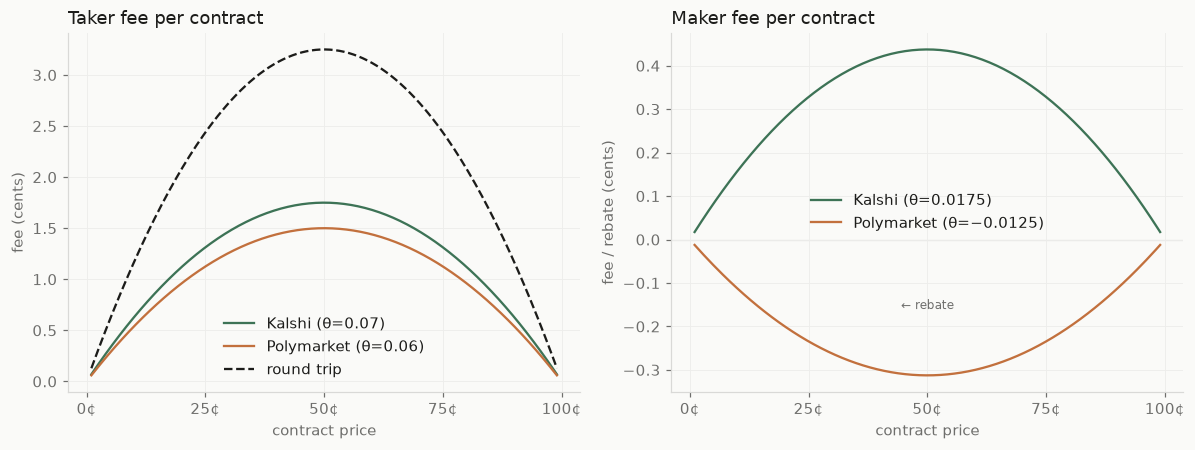

In [3]:
p = np.linspace(0.01, 0.99, 200)

k_taker = 0.07 * p * (1 - p) * 100   # cents
k_maker = 0.0175 * p * (1 - p) * 100
p_taker = 0.06 * p * (1 - p) * 100
p_maker = -0.0125 * p * (1 - p) * 100
combined_taker = k_taker + p_taker

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)

# Taker fees
ax1.plot(p, k_taker, color=GREEN, lw=1.5, label="Kalshi (θ=0.07)")
ax1.plot(p, p_taker, color=CLAY, lw=1.5, label="Polymarket (θ=0.06)")
ax1.plot(p, combined_taker, color=INK, lw=1.5, ls="--", label="round trip")
ax1.set_title("Taker fee per contract", color=INK)
ax1.set_xlabel("contract price")
ax1.set_ylabel("fee (cents)")
ax1.legend(frameon=False)
ax1.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
ax1.set_xticklabels(["0¢", "25¢", "50¢", "75¢", "100¢"])

# Maker fees / rebates
ax2.plot(p, k_maker, color=GREEN, lw=1.5, label="Kalshi (θ=0.0175)")
ax2.plot(p, p_maker, color=CLAY, lw=1.5, label="Polymarket (θ=−0.0125)")
ax2.axhline(0, color=BASELINE, lw=0.8, zorder=0)
ax2.set_title("Maker fee per contract", color=INK)
ax2.set_xlabel("contract price")
ax2.set_ylabel("fee / rebate (cents)")
ax2.legend(frameon=False)
ax2.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
ax2.set_xticklabels(["0¢", "25¢", "50¢", "75¢", "100¢"])
ax2.annotate("← rebate", xy=(0.5, -0.16), fontsize=8, color=MUTED, ha="center")

fig.tight_layout()
plt.show()

## Data
Kalshi and Polymarket provide websocket data of their orderbooks.\
I collected websocket data on matched MLB game winner markets that covered:
- 3 days (July 30th, 31st, and August 1st 2026)
- 40 Games

Note
- timestamps are the exchanges' own event times, in UTC
    - evening games run past midnight UTC, so the build info below shows an end date one day past the last collection day
- episodes starting within 30 seconds of a collector start or reconnect are excluded
    - stale forward-filled book state around those events produces phantom arbs
- A date column is included because MLB teams play against each other multiple times

### Connect To DB

In [4]:
import os

DB_PATH = Path(os.environ.get("ARB_DB", "../db/arb_orderbooks.db"))
con = duckdb.connect(DB_PATH, read_only=True)

### Load Data

In [5]:
all_episodes = con.sql("SELECT * FROM arb_episodes").pl()

info = con.sql("""
    SELECT data_start, data_end, n_games, n_states, n_episodes, n_profitable
    FROM arb_build_info
""").fetchone()

display(Markdown(
    f"| | |\n|---|---|\n"
    f"| **dates** | {info[0]} to {info[1]} |\n"
    f"| **games** | {info[2]} |\n"
    f"| **cross-platform book states** | {info[3]:,} |\n"
    f"| **opportunities before fees** | {info[4]:,} |\n"
    f"| **opportunities after fees** | {info[5]:,} |"
))

| | |
|---|---|
| **dates** | 2026-07-30 to 2026-08-02 |
| **games** | 40 |
| **cross-platform book states** | 3,529,564 |
| **opportunities before fees** | 8,870 |
| **opportunities after fees** | 480 |

## How Many Opportunities Before Fees?

Every time one platform's best bid exceeds the other's best ask the books are "crossed".\
That is a "gross" arbitrage opportunity, which is ignoring fees.

In [6]:
n_gross = len(all_episodes)
n_games = all_episodes["game_key"].n_unique()

print(f"Opportunities before fees: {n_gross}")
print(f"Games: {n_games}")
print(f"Gross opportunities per game: {n_gross / n_games}")

Opportunities before fees: 8870
Games: 40
Gross opportunities per game: 221.75


There are about 220 gross arbitrage opportunities per game before fees

## How Many Opportunities After Fees?

Most of those crossings are smaller than the round-trip taker fee.\
Only episodes where the peak deviation exceeds the combined fees could be real opportunities.

In [7]:
episodes = all_episodes.filter(pl.col("max_net_arb") > 0)
n_net = len(episodes)

print(f"Opportunities after fees: {n_net}")
print(f"Games: {n_games}")
print(f"Net opportunities per game: {n_net / n_games:.1f}")

Opportunities after fees: 480
Games: 40
Net opportunities per game: 12.0


Most gross opportunities are below the round-trip cost.

There are about 12 potentially real arbitrage opportunities per game.

### How Much Are These Opportunities Worth?

Each episode has a value which is the peak net arb per contract times the bottleneck liquidity.

This is the most you could have made if you filled the entire bottleneck at the best moment.

In [8]:
episodes = episodes.with_columns(
    (pl.col("bottleneck_liquidity") * pl.col("max_net_arb")).alias("max_dollar_value")
)

total_value = episodes["max_dollar_value"].sum()

print(f"Total theoretical value: ${total_value:.2f}")
print(f"Per game: ${total_value / n_games:.2f}")

Total theoretical value: $405.89
Per game: $10.15


In [9]:
episodes.sort("max_dollar_value", descending=True).head(15).select(
    pl.col("game_key").alias("game"),
    pl.col("game_date").alias("date"),
    pl.col("direction"),
    fmt_cents("max_net_arb").alias("peak arb/contract"),
    pl.col("bottleneck_liquidity").round(0).cast(pl.Int64).alias("bottleneck"),
    pl.format("${}", pl.col("max_dollar_value").round(2)).alias("value"),
)

game,date,direction,peak arb/contract,bottleneck,value
"""TEX@TB-2026-07-30""",2026-07-30,"""buy_kalshi""","""0.56¢""",10000,"""$56.16"""
"""NYY@CWS-2026-07-30""",2026-07-30,"""buy_kalshi""","""1.27¢""",3463,"""$43.89"""
"""NYY@CHC-2026-08-01""",2026-08-01,"""buy_poly""","""19.41¢""",138,"""$26.79"""
"""CHC@STL-2026-07-30""",2026-07-30,"""buy_kalshi""","""2.8¢""",927,"""$25.93"""
"""CHC@STL-2026-07-30""",2026-07-30,"""buy_kalshi""","""0.86¢""",3000,"""$25.76"""
"""NYY@CHC-2026-08-01""",2026-08-01,"""buy_poly""","""9.89¢""",170,"""$16.81"""
"""KC@COL-2026-08-01""",2026-08-01,"""buy_kalshi""","""1.83¢""",529,"""$9.66"""
"""SF@SD-2026-07-31""",2026-07-31,"""buy_kalshi""","""1.51¢""",609,"""$9.2"""
"""AZ@CLE-2026-08-01""",2026-08-01,"""buy_poly""","""0.09¢""",9561,"""$8.95"""
"""MIA@NYM-2026-07-30""",2026-07-30,"""buy_kalshi""","""8.12¢""",107,"""$8.71"""


### By Bottleneck Liquidity

Not all 480 opportunities have real size behind them.\
If the bottleneck liquidity is one contract you can make a couple pennies which is nothing to write home about.

Below we see how many opportunities exist at different levels of bottleneck liquidity.

In [10]:
liq_counts = pl.DataFrame({
    "total": [len(episodes)],
    "gte_1": [int((episodes["bottleneck_liquidity"] >= 1).sum())],
    "gte_10": [int((episodes["bottleneck_liquidity"] >= 10).sum())],
    "gte_50": [int((episodes["bottleneck_liquidity"] >= 50).sum())],
    "gte_100": [int((episodes["bottleneck_liquidity"] >= 100).sum())],
    "gte_500": [int((episodes["bottleneck_liquidity"] >= 500).sum())],
    "gte_1000": [int((episodes["bottleneck_liquidity"] >= 1_000).sum())],
    "gte_5000": [int((episodes["bottleneck_liquidity"] >= 5_000).sum())],
})

liq_counts.select(
    fmt_count("total").alias("total"),
    fmt_count("gte_1").alias("≥1"),
    fmt_count("gte_10").alias("≥10"),
    fmt_count("gte_50").alias("≥50"),
    fmt_count("gte_100").alias("≥100"),
    fmt_count("gte_500").alias("≥500"),
    fmt_count("gte_1000").alias("≥1,000"),
    fmt_count("gte_5000").alias("≥5,000"),
)

total,≥1,≥10,≥50,≥100,≥500,"≥1,000","≥5,000"
"""480""","""416""","""170""","""104""","""76""","""24""","""11""","""2"""


Note that fractional contracts exist which is why total is not equal to >=1

A few opportunities exist with decent volume, but (480-170)/480 = 65% don't even have 10 contracts of volume.

## How Big Are the Opportunities?

For each episode we look at the peak net arb per contract. That is the most you could have made on a single contract at the best moment in the episode, after fees.

In [11]:
thresholds = [0, 1, 10, 100, 1_000]
labels = ["all", "≥1", "≥10", "≥100", "≥1,000"]

rows = []
for thresh, label in zip(thresholds, labels):
    subset = episodes.filter(pl.col("bottleneck_liquidity") >= thresh) if thresh > 0 else episodes
    arb = subset["max_net_arb"]
    rows.append({
        "liquidity": label,
        "count": len(subset),
        "median_c": float(arb.median()) * 100 if len(subset) > 0 else 0,
        "mean_c": float(arb.mean()) * 100 if len(subset) > 0 else 0,
    })

size_by_liq = pl.DataFrame(rows)
size_by_liq.select(
    pl.col("liquidity").alias("bottleneck"),
    fmt_count("count").alias("episodes"),
    pl.format("{}¢", pl.col("median_c").round(2)).alias("median"),
    pl.format("{}¢", pl.col("mean_c").round(2)).alias("mean"),
)

bottleneck,episodes,median,mean
"""all""","""480""","""0.48¢""","""1.48¢"""
"""≥1""","""416""","""0.49¢""","""1.57¢"""
"""≥10""","""170""","""0.33¢""","""1.47¢"""
"""≥100""","""76""","""0.44¢""","""1.31¢"""
"""≥1,000""","""11""","""0.15¢""","""0.38¢"""


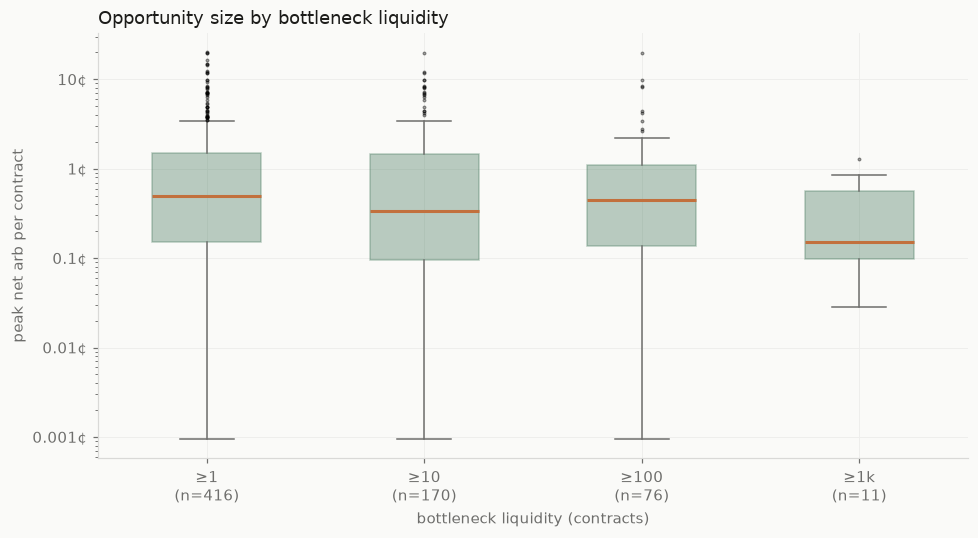

In [12]:
box_thresholds = [1, 10, 100, 1_000]
box_labels = ["≥1", "≥10", "≥100", "≥1k"]

box_data = []
box_positions = []
box_tick_labels = []

for i, (thresh, label) in enumerate(zip(box_thresholds, box_labels)):
    subset = episodes.filter(pl.col("bottleneck_liquidity") >= thresh)
    if len(subset) > 0:
        box_data.append(subset["max_net_arb"].to_numpy() * 100)
        box_positions.append(i)
        box_tick_labels.append(f"{label}\n(n={len(subset)})")

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker=".", markersize=3, color=MUTED, alpha=0.5),
    medianprops=dict(color=CLAY, lw=2),
    whiskerprops=dict(color=MUTED, lw=1),
    capprops=dict(color=MUTED, lw=1),
)

for patch in bp["boxes"]:
    patch.set_facecolor(GREEN)
    patch.set_alpha(0.35)
    patch.set_edgecolor(GREEN)

ax.set_yscale("log", base=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:g}¢"))
ax.set_xticks(box_positions)
ax.set_xticklabels(box_tick_labels)
ax.set_ylabel("peak net arb per contract")
ax.set_xlabel("bottleneck liquidity (contracts)")
ax.set_title("Opportunity size by bottleneck liquidity", color=INK)

fig.tight_layout()
plt.show()

We can see most opportunities are for less than 1 cent especially at higher liquidity levels.

## How Long Do Opportunities Persist?

An opportunity that disappears in 100ms is not the same as one that lasts 10 seconds.\
The taker delay on Polymarket makes anything less than 1-3 seconds impossible to exploit.

Below we break down duration by bottleneck liquidity to see whether the tradeable opportunities last long enough to act on.

In [13]:
thresholds = [0, 1, 10, 100, 1_000]
labels = ["all", "≥1", "≥10", "≥100", "≥1,000"]

rows = []
for thresh, label in zip(thresholds, labels):
    subset = episodes.filter(pl.col("bottleneck_liquidity") >= thresh) if thresh > 0 else episodes
    dur = subset["duration_s"]
    rows.append({
        "liquidity": label,
        "count": len(subset),
        "median_s": float(dur.median()) if len(subset) > 0 else 0,
        "mean_s": float(dur.mean()) if len(subset) > 0 else 0,
    })

dur_by_liq = pl.DataFrame(rows)
dur_by_liq.select(
    pl.col("liquidity").alias("bottleneck"),
    fmt_count("count").alias("episodes"),
    fmt_secs("median_s").alias("median"),
    fmt_secs("mean_s").alias("mean"),
)

bottleneck,episodes,median,mean
"""all""","""480""","""0.1s""","""1.3s"""
"""≥1""","""416""","""0.1s""","""1.3s"""
"""≥10""","""170""","""0.1s""","""0.6s"""
"""≥100""","""76""","""0.1s""","""0.7s"""
"""≥1,000""","""11""","""0.0s""","""0.2s"""


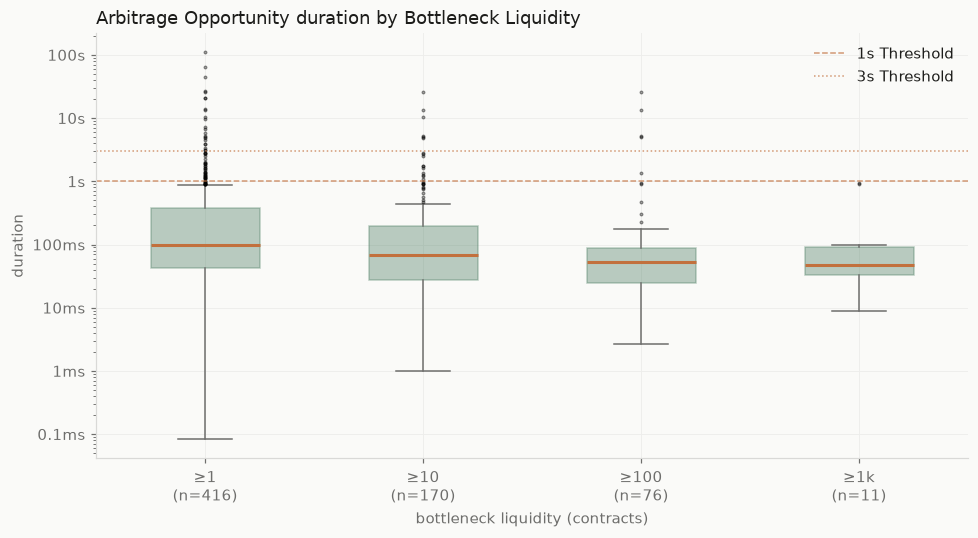

In [14]:
box_thresholds = [1, 10, 100, 1_000]
box_labels = ["≥1", "≥10", "≥100", "≥1k"]

box_data = []
box_positions = []
box_tick_labels = []

for i, (thresh, label) in enumerate(zip(box_thresholds, box_labels)):
    subset = episodes.filter(pl.col("bottleneck_liquidity") >= thresh)
    if len(subset) > 0:
        box_data.append(subset["duration_s"].to_numpy())
        box_positions.append(i)
        box_tick_labels.append(f"{label}\n(n={len(subset)})")

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker=".", markersize=3, color=MUTED, alpha=0.5),
    medianprops=dict(color=CLAY, lw=2),
    whiskerprops=dict(color=MUTED, lw=1),
    capprops=dict(color=MUTED, lw=1),
)

for patch in bp["boxes"]:
    patch.set_facecolor(GREEN)
    patch.set_alpha(0.35)
    patch.set_edgecolor(GREEN)

ax.set_yscale("log", base=10)

def fmt_duration(x, _):
    if x >= 1:
        return f"{x:g}s"
    return f"{x * 1000:g}ms"

ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_duration))
ax.axhline(1, color=CLAY, ls="--", lw=1, alpha=0.7, label="1s Threshold")
ax.axhline(3, color=CLAY, ls=":", lw=1, alpha=0.7, label="3s Threshold")

ax.set_xticks(box_positions)
ax.set_xticklabels(box_tick_labels)
ax.set_ylabel("duration")
ax.set_xlabel("bottleneck liquidity (contracts)")
ax.set_title("Arbitrage Opportunity duration by Bottleneck Liquidity", color=INK)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

We can see that the vast majority of opportunities disappear before the 1 second Polymarket taker delay. Thus these are not exploitable in practice.

## The Biggest Opportunity Up Close

The biggest opportunity in the data was worth $56.16, during TEX@TB on July 30th. The price gap was tiny, 0.56¢ per contract after fees, but it had 10,000 contracts of bottleneck liquidity behind it. It appeared at 16:23:52 UTC and lasted 25 milliseconds.

Its direction was buy on Kalshi, sell on Polymarket, so only two prices matter: the Kalshi best ask (what you pay) and the Polymarket best bid (what you receive). Whenever the Polymarket bid sits above the Kalshi ask, the difference is yours (before fees).

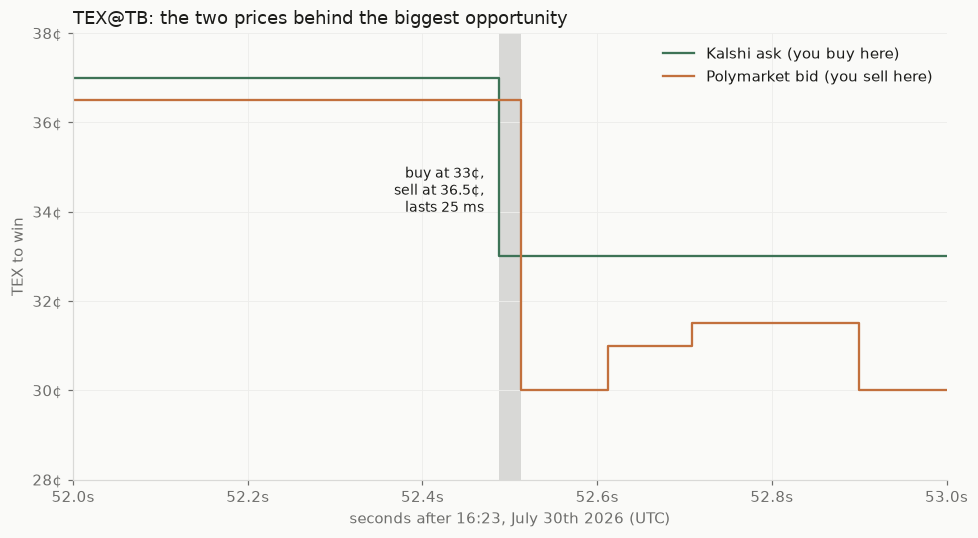

In [15]:
import datetime as dt

import matplotlib.dates as mdates

window = con.sql("""
    SELECT timestamp, k_ask, p_bid
    FROM arb_states
    WHERE game_key = 'TEX@TB-2026-07-30'
      AND timestamp BETWEEN TIMESTAMP '2026-07-30 16:23:50'
                        AND TIMESTAMP '2026-07-30 16:23:56'
    ORDER BY timestamp
""").pl()

ep_start = dt.datetime(2026, 7, 30, 16, 23, 52, 488000)
ep_end = dt.datetime(2026, 7, 30, 16, 23, 52, 512507)

fig, ax = plt.subplots(figsize=(9, 5))

t = window["timestamp"].to_list()
ax.step(t, window["k_ask"], where="post", color=GREEN, lw=1.5,
        label="Kalshi ask (you buy here)")
ax.step(t, window["p_bid"], where="post", color=CLAY, lw=1.5,
        label="Polymarket bid (you sell here)")

ax.axvspan(ep_start, ep_end, color=INK, alpha=0.15, lw=0)
ax.annotate("buy at 33¢,\nsell at 36.5¢,\nlasts 25 ms", xy=(ep_start, 0.34),
            xytext=(-10, 0), textcoords="offset points",
            fontsize=9, color=INK, ha="right")

ax.set_xlim(dt.datetime(2026, 7, 30, 16, 23, 52),
            dt.datetime(2026, 7, 30, 16, 23, 53))
ax.set_ylim(0.28, 0.38)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda y, _: f"{y * 100:g}¢"))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: mdates.num2date(x).strftime("%S.%f")[:4] + "s"))
ax.set_ylabel("TEX to win")
ax.set_xlabel("seconds after 16:23, July 30th 2026 (UTC)")
ax.set_title("TEX@TB: the two prices behind the biggest opportunity", color=INK)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

So what actually happened in the game? The MLB play-by-play has the answer. Bottom of the 1st, 0-0, two outs, bases empty. Junior Caminero hit a ball 108 mph off the bat toward dead center, 407 feet. Off the bat it looked like a go-ahead home run for TB, close enough that the umpires reviewed the call. The ball went in play at 16:23:51.2 and both platforms slashed TEX's price while it was in the air, from about 37¢ to about 31¢.

Kalshi cut first. Its ask dropped from 37¢ to 33¢ while Polymarket's bid was still sitting at 36.5¢, and for 25 milliseconds you could buy TEX on Kalshi at 33¢ and sell on Polymarket at 36.5¢. Then Polymarket's bid collapsed too and the books agreed again. The ball was caught at the wall and the flyout was upheld on review.

The other large opportunities in our data look the same. They occurred during games at moments of sharp repricing. These are races between the two platforms' market makers, and the window closes as soon as the slower one catches up.

## Which Direction Do Opportunities Go?

Every opportunity has a direction. buy_kalshi means buy on Kalshi and sell on Polymarket, buy_poly is the reverse. If one platform were systematically slower or cheaper than the other, one direction would dominate.

In [16]:
episodes.group_by("direction").agg(
    pl.len().alias("count"),
    pl.col("max_dollar_value").sum().alias("value"),
).sort("direction").select(
    pl.col("direction"),
    fmt_count("count").alias("opportunities"),
    pl.format("${}", pl.col("value").round(2)).alias("theoretical value"),
)

direction,opportunities,theoretical value
"""buy_kalshi""","""240""","""$257.24"""
"""buy_poly""","""240""","""$148.65"""


The count split is dead even, 240 to 240 — on any given event either book can be the one that reprices first. By theoretical value, buy_kalshi leads ($257 to $149), but that is driven by a handful of large-bottleneck episodes: the two largest ($56 and $44, both on July 30th) account for most of the gap.

## Conclusion

In [17]:
persistent = episodes.filter(pl.col("duration_s") >= 1)
n_persistent = len(persistent)
value_persistent = persistent["max_dollar_value"].sum()

print(f"Opportunities lasting 1s or longer: {n_persistent}")
print(f"Their total theoretical value: ${value_persistent:.2f}")
print(f"Per game: ${value_persistent / n_games:.2f}")

Opportunities lasting 1s or longer: 71
Their total theoretical value: $27.38
Per game: $0.68


Arbitrage between Kalshi and Polymarket exists on paper. Over 3 days and 40 games 480 opportunities were bigger than the round-trip taker fees.

In practice it cannot be exploited.

71 opportunities persisted for 1 second or longer, together worth about $27.38 in theory, or $0.68 per game. But duration is only known after the fact. At the moment the books cross there is no way to tell whether the opportunity will last 1 second or 100 milliseconds, and the majority vanish in under a second. Firing at every crossing means the Polymarket leg sits in the 1-3 second taker delay while most of the opportunities close, leaving unfilled or one-sided positions. So the persistent opportunities cannot be separated from the rest in real time, and the pool as a whole is not tradeable.

The two books are effectively one market. They price within fees of each other almost all the time, and the gaps that do open are closed faster than a retail participant can act.